In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os, re, glob
from pathlib import Path

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

LOG_ROOT = "../logs/rsl_rl/boxpush"

policy_results = []
baseline_results = []

for npz_path in sorted(glob.glob(os.path.join(LOG_ROOT, "*/ur_rtde_logs/*.npz"))):
    d = np.load(npz_path)
    run_dir = Path(npz_path).parent.parent.name

    actual_q = d["actual_q"]
    expected_q = d["expected_q"]
    error_per_step = np.linalg.norm(actual_q - expected_q, axis=1)
    mid = len(error_per_step)

    kp = m.group(1) if (m := re.search(r"kp([\d.]+)", run_dir)) else "?"
    kd = m.group(1) if (m := re.search(r"kd([\d.]+)", run_dir)) else "?"
    scale_from_dir = m.group(1) if (m := re.search(r"scale([\d.]+)", run_dir)) else "?"
    gain = str(float(d["gain"]))
    lookahead = str(float(d["lookahead_time"]))
    action_scale = float(d["action_scale"])

    entry = {
        "kp": kp, "kd": kd, "action_scale": str(action_scale),
        "gain": gain, "lookahead": lookahead,
        "steps": d["steps"][:mid],
        "error": error_per_step[:mid],
        "mean_error": error_per_step[:mid].mean(),
        "max_error": error_per_step[:mid].max(),
    }

    if action_scale == 0:
        baseline_results.append(entry)
    else:
        policy_results.append(entry)

ALL_PARAMS = ["kp", "kd", "action_scale", "gain", "lookahead"]
SERVO_PARAMS = ["gain", "lookahead"]
print(f"Loaded {len(policy_results)} policy + {len(baseline_results)} baseline results (1st half only)")
for p in ALL_PARAMS:
    vals = sorted(set(r[p] for r in policy_results))
    print(f"  {p}: {vals}")
if baseline_results:
    print(f"  baseline servo configs: {len(baseline_results)}")

Loaded 900 policy + 9 baseline results (1st half only)
  kp: ['100.0', '150.0', '200.0', '300.0', '400.0']
  kd: ['10.0', '100.00', '15.0', '15.00', '20.0', '22.50', '25.00', '30.0', '30.00', '37.50', '40.0', '45.00', '50.00', '60.0', '60.00', '75.00', '80.0']
  action_scale: ['0.05', '0.1', '0.15', '0.2', '0.25']
  gain: ['100.0', '200.0', '400.0']
  lookahead: ['0.05', '0.1', '0.2']
  baseline servo configs: 9


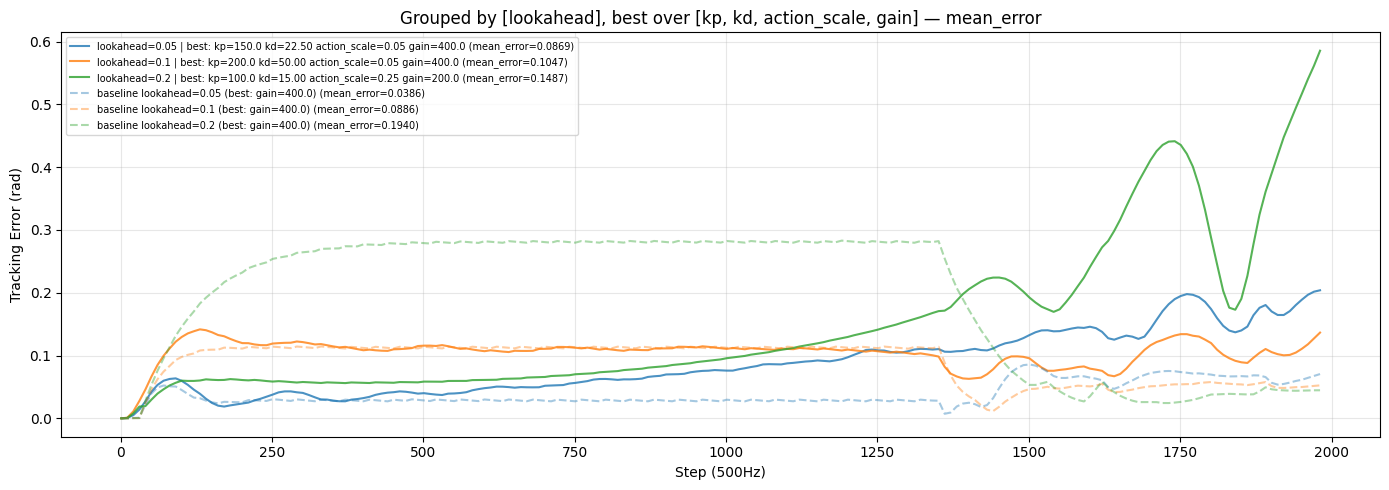

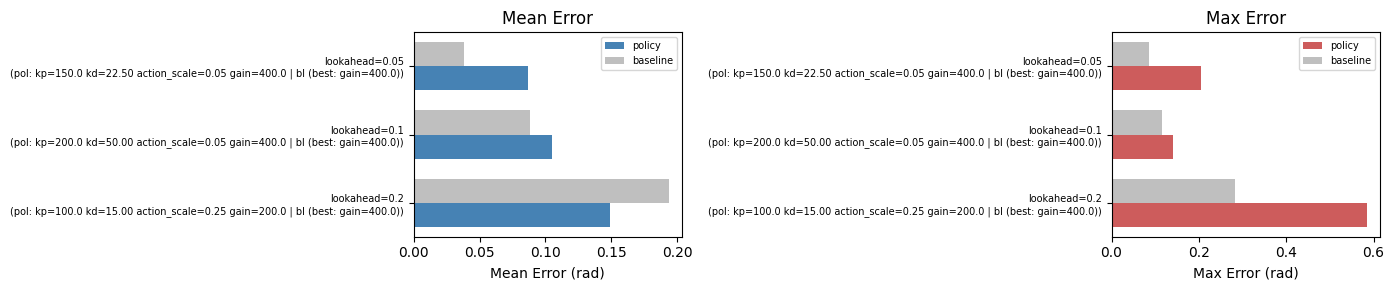

In [ ]:
#-- Change these and re-run (Ctrl+Enter) --
GROUP_BY = ["lookahead"]  # any subset of: kp, kd, action_scale, gain, lookahead
METRIC = "mean_error"             # "mean_error" or "max_error"
#-------------------------------------------

optimized = [p for p in ALL_PARAMS if p not in GROUP_BY]

# Group policy results
groups = {}
for r in policy_results:
    k = tuple(r[p] for p in GROUP_BY)
    if k not in groups or r[METRIC] < groups[k][METRIC]:
        groups[k] = r

# Group baseline results by the servo params present in GROUP_BY
baseline_group_params = [p for p in GROUP_BY if p in SERVO_PARAMS]
baseline_optimized = [p for p in SERVO_PARAMS if p not in GROUP_BY]
has_servo_grouping = len(baseline_group_params) > 0

baseline_groups = {}
if baseline_results:
    if has_servo_grouping:
        for r in baseline_results:
            k = tuple(r[p] for p in baseline_group_params)
            if k not in baseline_groups or r[METRIC] < baseline_groups[k][METRIC]:
                baseline_groups[k] = r
    else:
        best_bl = min(baseline_results, key=lambda r: r[METRIC])
        baseline_groups[("best",)] = best_bl

def baseline_key_for(group_key):
    if not has_servo_grouping:
        return ("best",)
    return tuple(v for p, v in zip(GROUP_BY, group_key) if p in SERVO_PARAMS)

def baseline_desc(bk):
    """Describe what was optimized in the baseline for this group."""
    if bk not in baseline_groups:
        return ""
    bl = baseline_groups[bk]
    od = " ".join(f"{p}={bl[p]}" for p in baseline_optimized)
    return f" (best: {od})" if od else ""

def make_label(k, short=False):
    best = groups[k]
    gd = " ".join(f"{p}={v}" for p, v in zip(GROUP_BY, k))
    od = " ".join(f"{p}={best[p]}" for p in optimized)
    if short:
        return f"{gd}\n({od})" if optimized else gd
    return f"{gd} | best: {od} ({METRIC}={best[METRIC]:.4f})" if optimized else f"{gd} ({METRIC}={best[METRIC]:.4f})"

# ---- Time series ----
fig, ax = plt.subplots(figsize=(14, 5))
step = 10
cmap = plt.rcParams['axes.prop_cycle'].by_key()['color']
sorted_group_keys = sorted(groups)
key_colors = {k: cmap[i % len(cmap)] for i, k in enumerate(sorted_group_keys)}

for k in sorted_group_keys:
    ax.plot(groups[k]["steps"][::step], groups[k]["error"][::step],
            label=make_label(k), alpha=0.8, color=key_colors[k])

plotted_bl_keys = set()
for k in sorted_group_keys:
    bk = baseline_key_for(k)
    if bk in baseline_groups and bk not in plotted_bl_keys:
        bl = baseline_groups[bk]
        if has_servo_grouping:
            bl_label = "baseline " + " ".join(f"{p}={v}" for p, v in zip(baseline_group_params, bk))
        else:
            bl_label = "baseline"
        bl_label += baseline_desc(bk) + f" ({METRIC}={bl[METRIC]:.4f})"
        ax.plot(bl["steps"][::step], bl["error"][::step],
                label=bl_label, linestyle='--', color=key_colors[k], alpha=0.4)
        plotted_bl_keys.add(bk)

ax.set_xlabel("Step (500Hz)")
ax.set_ylabel("Tracking Error (rad)")
ax.set_title(f"Grouped by [{', '.join(GROUP_BY)}], best over [{', '.join(optimized)}] — {METRIC}")
ax.legend(fontsize=7)
ax.grid(True, alpha=0.3)
plt.tight_layout()

# ---- Bar chart ----
sorted_keys = sorted(groups, key=lambda k: groups[k][METRIC])
y_pos = np.arange(len(sorted_keys))
bar_h = 0.35

# Build labels with baseline info
labels = []
for k in sorted_keys:
    gd = " ".join(f"{p}={v}" for p, v in zip(GROUP_BY, k))
    od = " ".join(f"{p}={groups[k][p]}" for p in optimized)
    bk = baseline_key_for(k)
    bl_od = baseline_desc(bk)
    pol_line = f"pol: {od}" if od else "pol"
    bl_line = f"bl{bl_od}" if bl_od else "bl"
    labels.append(f"{gd}\n({pol_line} | {bl_line})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, max(3, len(groups) * 0.6)))

ax1.barh(y_pos + bar_h/2, [groups[k]["mean_error"] for k in sorted_keys], bar_h, color='steelblue', label='policy')
ax2.barh(y_pos + bar_h/2, [groups[k]["max_error"] for k in sorted_keys], bar_h, color='indianred', label='policy')

bl_mean, bl_max = [], []
for k in sorted_keys:
    bk = baseline_key_for(k)
    if bk in baseline_groups:
        bl_mean.append(baseline_groups[bk]["mean_error"])
        bl_max.append(baseline_groups[bk]["max_error"])
    else:
        bl_mean.append(0)
        bl_max.append(0)

ax1.barh(y_pos - bar_h/2, bl_mean, bar_h, color='gray', alpha=0.5, label='baseline')
ax2.barh(y_pos - bar_h/2, bl_max, bar_h, color='gray', alpha=0.5, label='baseline')

for ax, title in [(ax1, "Mean Error"), (ax2, "Max Error")]:
    ax.set_yticks(y_pos); ax.set_yticklabels(labels, fontsize=7)
    ax.set_xlabel(f"{title} (rad)"); ax.set_title(title)
    ax.invert_yaxis(); ax.legend(fontsize=7)

plt.tight_layout()